In [26]:
import matplotlib.pyplot as plt
import json
import numpy as np

from common import *

data_file = open("./results.json", "r")

data = json.load(data_file)


In [27]:
# Temps en fonction du nombre d'élément pour chacune des approche
times = []

data_g1 = data[TEST_FILES[0]]
times.append([(int(nbT), data_g1[nbT]["time"]) for nbT in data_g1])

data_rome = data[TEST_FILES[1]]
times.append([(int(nbT), data_rome[nbT]["time"]) for nbT in data_rome])

data_ny = data[TEST_FILES[2]]
times.append([(int(nbT), data_ny[nbT]["time"]) for nbT in data_ny])


In [28]:
# Calcules des accélérations

acc = []

time_0_base_speed = times[0][0][1]
acc.append([(int(nbT), time_0_base_speed / data_g1[nbT]["time"]) for nbT in data_g1])

time_1_base_speed = times[1][0][1]
acc.append([(int(nbT), time_1_base_speed / data_rome[nbT]["time"]) for nbT in data_rome])

time_2_base_speed = times[2][0][1]
acc.append([(int(nbT), time_2_base_speed / data_ny[nbT]["time"]) for nbT in data_ny])

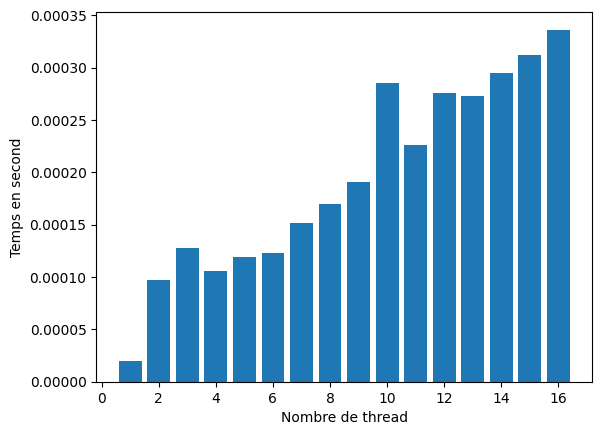

In [29]:
#plot times
im0_times = [t[1] for t in times[0]]

plt.bar(range(1,NB_THREAD_MAX+1) ,im0_times, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
# plt.title(f"Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread pour {TEST_SIZE[-1]} éléments.")

plt.savefig("./images/g1_times.svg")
plt.show()


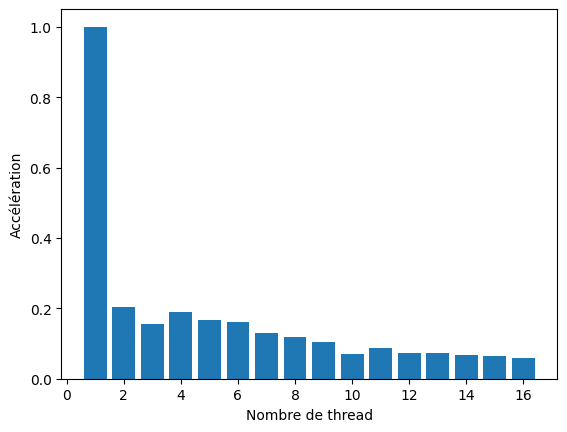

1.0


In [30]:

#plot acc

im0_acc = [t[1] for t in acc[0]]

plt.bar(range(1,NB_THREAD_MAX+1) ,im0_acc, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Accélération")

plt.savefig("./images/g1_acc.svg")
plt.show()

print(max(im0_acc))


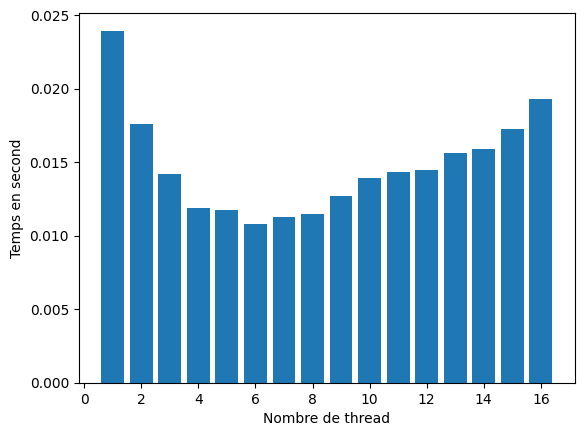

In [31]:
#plot time
im1_times = [t[1] for t in times[1]]

plt.bar(range(1,NB_THREAD_MAX+1) ,im1_times, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
# plt.title(f"Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread pour {TEST_SIZE[-1]} éléments.")

plt.savefig("./images/rome_times.svg")
plt.show()


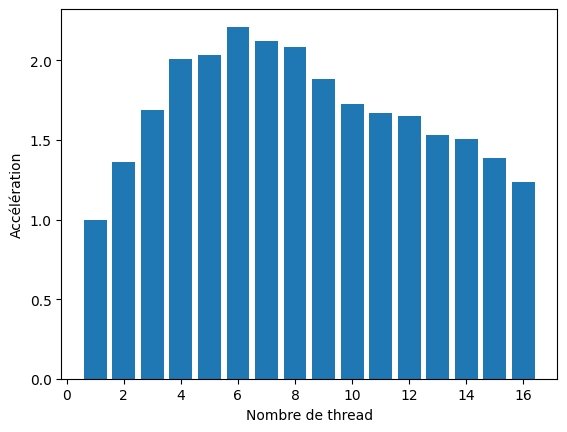

2.211508625466366


In [32]:
# plot acc
im1_acc = [t[1] for t in acc[1]]

plt.bar(range(1,NB_THREAD_MAX+1) ,im1_acc, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Accélération")
# plt.title(f"Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread pour {TEST_SIZE[-1]} éléments.")

plt.savefig("./images/rome_acc.svg")
plt.show()

print(max(im1_acc))


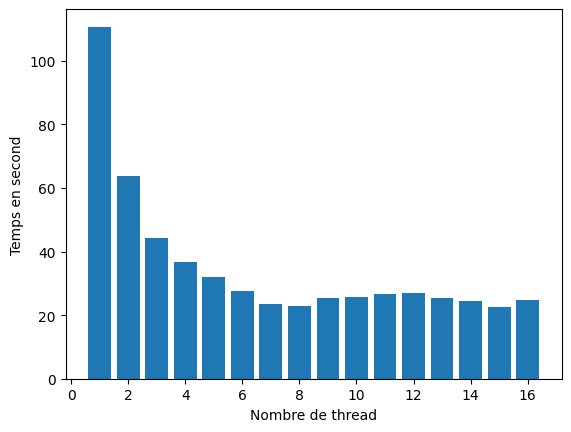

In [33]:
#plot times
im2_times = [t[1] for t in times[2]]

plt.bar(range(1,NB_THREAD_MAX+1) ,im2_times, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
# plt.title(f"Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread pour {TEST_SIZE[-1]} éléments.")

plt.savefig("./images/ny_times.svg")
plt.show()


4.9348559610250105


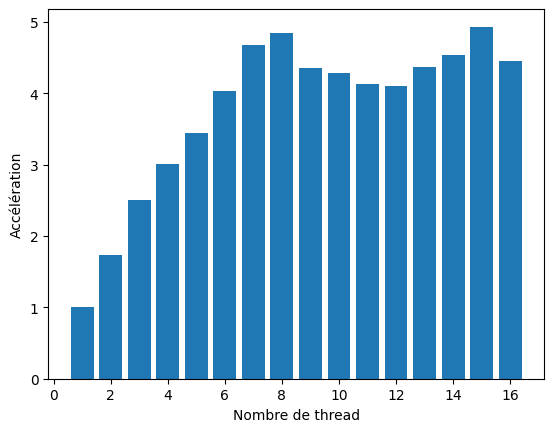

In [34]:
#plot acc
ny_acc = [t[1] for t in acc[2]]
best_acc = max(ny_acc)
print(best_acc)

s = 1/best_acc
Amdhal = lambda n : 1/(s + (1-s)/n)
plt.bar(range(1,NB_THREAD_MAX+1) ,ny_acc, label="_ignore")
X = np.arange(1e-16,16+1e-16, 1)
plt.xlabel("Nombre de thread")
plt.ylabel("Accélération")

plt.savefig("./images/ny_acc.svg")
plt.show()
